In [1]:
import pandas as pd 
import numpy as np

In [ ]:
df=pd.read_csv(r"C:\Users\SHILA\OneDrive\Desktop\PYTHON\ML_practiceDays\Datasets\placement.csv")
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.2 KB


In [4]:
df=df.iloc[:,1:]

In [5]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [6]:
import matplotlib.pyplot as plt

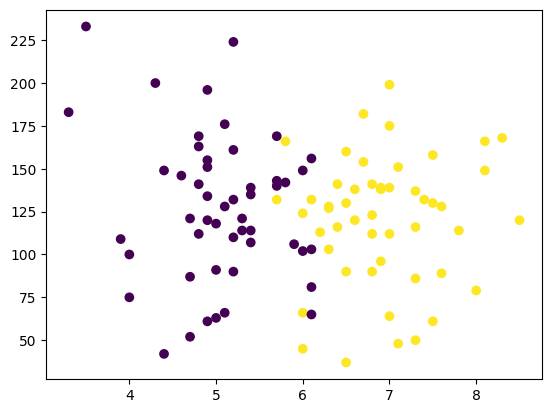

In [7]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [8]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [9]:
x.shape

(100, 2)

In [10]:
y.shape

(100,)

In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train, y_test=train_test_split(x,y,test_size=0.1)

In [12]:
x_train

,cgpa,iq
63,6.3,128.0
44,7.5,61.0
0,6.8,123.0
28,5.2,90.0
10,6.0,45.0
...,...,...
32,7.0,139.0
50,3.5,233.0
3,7.4,132.0
34,4.8,163.0


In [13]:
y_train

63    1
44    1
0     1
28    0
10    1
     ..
32    1
50    0
3     1
34    0
27    1
Name: placement, Length: 90, dtype: int64

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)

In [16]:
x_train

array([[ 0.27025264,  0.07493153],
       [ 1.32015499, -1.61102796],
       [ 0.70771195, -0.05088634],
       [-0.69215784, -0.8812843 ],
       [ 0.00777705, -2.01364515],
       [-0.95463343, -1.61102796],
       [-0.25469853,  1.10663809],
       [-0.95463343,  0.65369375],
       [-1.39209274, -2.08913588],
       [ 0.53272823, -0.12637706],
       [-1.74206019, -0.62964855],
       [-0.95463343,  0.75434805],
       [ 0.62022009,  0.72918447],
       [ 0.79520381,  0.32656728],
       [ 0.79520381, -0.73030285],
       [ 1.32015499,  0.12525868],
       [-0.86714157, -1.56070081],
       [ 2.19507361, -0.12637706],
       [ 0.09526892,  0.77951162],
       [-1.21710902,  0.52787587],
       [-0.16720667,  1.03114737],
       [ 0.27025264,  0.04976796],
       [-0.95463343, -0.12637706],
       [ 0.00777705, -1.48521009],
       [-0.16720667,  0.42722158],
       [ 1.84510616,  0.6033666 ],
       [-0.86714157, -0.17670421],
       [-0.69215784,  2.49063469],
       [-0.69215784,

In [17]:
x_test=scaler.transform(x_test)
x_test

array([[-1.12961715, -0.95677502],
       [ 1.14517126, -1.88782728],
       [-1.04212529, -0.32768566],
       [ 0.09526892, -1.51037366],
       [ 1.84510616,  1.03114737],
       [ 0.44523637,  0.88016592],
       [-0.7796497 ,  0.07493153],
       [ 0.3577445 , -0.22703136],
       [ 0.09526892, -1.10775647],
       [-1.04212529,  0.402058  ]])

In [18]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()

In [19]:
clf.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
y_pred=clf.predict(x_test)

In [21]:
y_test

23    0
77    1
59    0
56    0
65    1
38    1
86    0
13    1
78    0
51    0
Name: placement, dtype: int64

In [22]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8

In [23]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

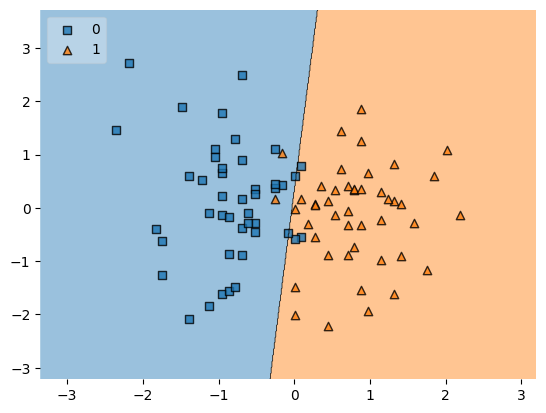

In [24]:
plot_decision_regions(x_train,y_train.values,clf=clf,legend=2)

In [25]:
import pickle

In [26]:
pickle.dump(clf,open('model.pkl','wb'))